In [1]:
import rdflib

Loading RDF from ./mappings/niosh_rdf_tutV2c.ttl...
Parsed 20304 triples
Analyzing schema structure...
Found 31 classes and 47 properties
RDF Schema Summary:
Total triples: 20304
Classes: 31
Properties: 47

Top 5 Classes (by instance count):
  ncit:C53321: 796 instances
  http://www.ebi.ac.uk/efo/EFO_0000487: 430 instances
  ncit:C25488: 430 instances
  ncit:C68568: 430 instances
  blkv:SubjectOfInvestigation: 430 instances

Top Properties (by usage):
  rdf:type: 4610 uses
  sio:SIO_000300: 2334 uses
  sio:SIO_000221: 1936 uses
  dcterms:type: 1850 uses
  obo:RO_0000053: 1420 uses
Building network representation...
Created network with 25 nodes and 94 edges


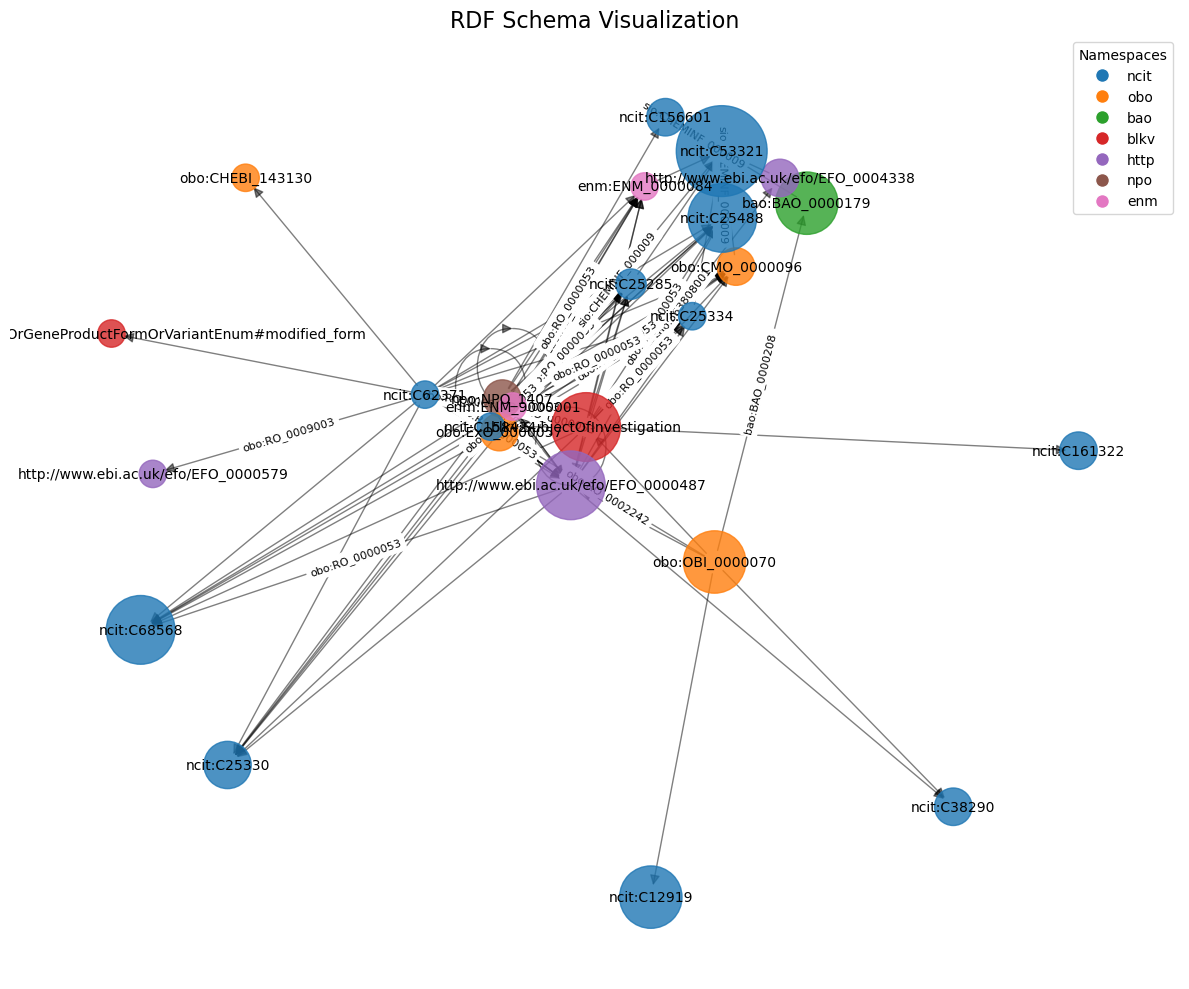

Class,Count,Properties
ncit:C53321,796,"dcterms:type, sio:SIO_000221, sio:SIO_000300"
http://www.ebi.ac.uk/efo/EFO_0000487,430,"ncit:C25330, ncit:C93410, obo:RO_0000053, obo:RO_0002242, rdfs:comment"
ncit:C25488,430,"sio:CHEMINF_000009, sio:SIO_000221, sio:SIO_000300"
ncit:C68568,430,"sio:SIO_000221, sio:SIO_000300"
blkv:SubjectOfInvestigation,430,"dcterms:type, ncit:C14419, ncit:C17177, ncit:C203602, ncit:C28421..."
obo:OBI_0000070,344,"bao:BAO_0000208, dcterms:description, ncit:C64542, obo:RO_0002242, obo:SCDO_0000482..."
bao:BAO_0000179,344,"dcterms:type, obo:OBI_0000679, sio:CHEMINF_000009, sio:SIO_000221, sio:SIO_000391"
ncit:C12919,344,"rdfs:comment, rdfs:label"
ncit:C25330,172,"ncit:C200447, ncit:C29844, sio:SIO_000221, sio:SIO_000300, sno:229784001"
npo:NPO_1407,86,"obo:RO_0000053, obo:SCDO_0000482, rdfs:comment, sio:SIO_000216"


ValueError: unsupported format character ';' (0x3b) at index 2527

In [18]:
# RDF Schema Visualization and Documentation
# This notebook provides tools to analyze, visualize, and document RDF schemas from Turtle files

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import rdflib
from rdflib import Graph, URIRef, Literal
import math
from rdflib.namespace import RDF, RDFS, XSD
from collections import defaultdict
import re
import io
from IPython.display import display, HTML, SVG, Image
import ipywidgets as widgets
import base64
import json
import warnings
warnings.filterwarnings('ignore')

# Class for analyzing and visualizing RDF schemas
class RDFSchemaAnalyzer:
    def __init__(self, file_path=None, graph=None):
        """Initialize with either a file path or an existing Graph."""
        self.graph = graph if graph else Graph()
        if file_path:
            self.load_file(file_path)
        
        # Data structures for schema information
        self.classes = set()
        self.properties = set()
        self.class_properties = defaultdict(set)
        self.property_domains = defaultdict(set)
        self.property_ranges = defaultdict(set)
        self.instance_counts = defaultdict(int)
        self.graph_network = None
        
    def load_file(self, file_path, format="turtle"):
        """Load an RDF file into the graph."""
        print(f"Loading RDF from {file_path}...")
        self.graph.parse(file_path, format=format)
        print(f"Parsed {len(self.graph)} triples")
        return self

    def analyze_schema(self):
        """Extract schema information from the graph."""
        print("Analyzing schema structure...")
        
        # Find all rdf:type statements to identify classes and instances
        for s, p, o in self.graph.triples((None, RDF.type, None)):
            self.classes.add(o)
            self.instance_counts[o] += 1
            
            # For each instance, extract its properties
            for pred, obj in self.graph.predicate_objects(s):
                if pred != RDF.type:
                    self.properties.add(pred)
                    self.class_properties[o].add(pred)
                    self.property_domains[pred].add(o)
                    
                    # Determine range types
                    if isinstance(obj, URIRef):
                        obj_types = list(self.graph.objects(obj, RDF.type))
                        if obj_types:
                            for t in obj_types:
                                self.property_ranges[pred].add(t)
                        else:
                            self.property_ranges[pred].add("Resource")
                    elif isinstance(obj, Literal):
                        if obj.datatype:
                            self.property_ranges[pred].add(obj.datatype)
                        else:
                            self.property_ranges[pred].add("Literal")
        
        print(f"Found {len(self.classes)} classes and {len(self.properties)} properties")
        return self
    
    def get_qname(self, uri):
        """Convert a URI to a QName using the known namespaces."""
        if not isinstance(uri, URIRef):
            return str(uri)
        
        for prefix, namespace in self.graph.namespaces():
            namespace_str = str(namespace)
            uri_str = str(uri)
            if uri_str.startswith(namespace_str):
                local_part = uri_str[len(namespace_str):]
                return f"{prefix}:{local_part}"
        
        return str(uri)
    
    def display_summary(self):
        """Display a summary of the schema."""
        print(f"RDF Schema Summary:")
        print(f"===================")
        print(f"Total triples: {len(self.graph)}")
        print(f"Classes: {len(self.classes)}")
        print(f"Properties: {len(self.properties)}")
        
        # Display top 5 classes by instance count
        print("\nTop 5 Classes (by instance count):")
        top_classes = sorted(self.instance_counts.items(), key=lambda x: x[1], reverse=True)[:5]
        for cls, count in top_classes:
            print(f"  {self.get_qname(cls)}: {count} instances")
        
        # Display top 5 properties by usage
        print("\nTop Properties (by usage):")
        property_usage = defaultdict(int)
        for s, p, o in self.graph:
            property_usage[p] += 1
        
        top_props = sorted(property_usage.items(), key=lambda x: x[1], reverse=True)[:5]
        for prop, count in top_props:
            print(f"  {self.get_qname(prop)}: {count} uses")
        
        return self
    
    def create_network_graph(self, max_nodes=50):
        """Create a NetworkX graph representation of the schema."""
        print("Building network representation...")
        G = nx.DiGraph()
        
        # Get top classes by instance count (to limit graph size)
        top_classes = sorted(self.instance_counts.items(), key=lambda x: x[1], reverse=True)[:max_nodes//2]
        important_classes = set(cls for cls, _ in top_classes)
        
        # Add class nodes
        for cls in important_classes:
            class_name = self.get_qname(cls)
            G.add_node(class_name, type="class", uri=str(cls), count=self.instance_counts[cls])
        
        # Add property connections between classes
        connections = []
        for cls in important_classes:
            for prop in self.class_properties[cls]:
                for range_cls in self.property_ranges[prop]:
                    if range_cls in important_classes:
                        connections.append((
                            self.get_qname(cls),
                            self.get_qname(range_cls),
                            self.get_qname(prop)
                        ))
        
        # Add edges for connections
        for src, dst, label in connections:
            if src in G.nodes and dst in G.nodes:
                G.add_edge(src, dst, label=label)
        
        self.graph_network = G
        print(f"Created network with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
        return self
    
    def visualize_network(self, figsize=(12, 10), title="RDF Schema Visualization"):
        """Visualize the schema network using NetworkX and Matplotlib."""
        if not self.graph_network:
            self.create_network_graph()
        
        G = self.graph_network
        
        plt.figure(figsize=figsize)
        plt.title(title, fontsize=16)
        
        # Create a layout for the nodes
        layout = nx.spring_layout(G, k=0.3, iterations=50, seed=42)
        
        # Create a colormap for different namespaces
        namespaces = set([node.split(':')[0] for node in G.nodes if ':' in node])
        colors = list(mcolors.TABLEAU_COLORS)
        color_map = {ns: colors[i % len(colors)] for i, ns in enumerate(namespaces)}
        
        # Node colors based on namespace
        node_colors = [color_map.get(node.split(':')[0], 'gray') if ':' in node else 'gray' for node in G.nodes]
        
        # Node sizes based on importance (instance count)
        node_sizes = [300 + G.nodes[node].get('count', 0) * 5 for node in G.nodes]
        
        # Draw the graph
        nx.draw_networkx_nodes(G, layout, node_color=node_colors, node_size=node_sizes, alpha=0.8)
        nx.draw_networkx_edges(G, layout, width=1.0, alpha=0.5, arrows=True, arrowsize=15)
        nx.draw_networkx_labels(G, layout, font_size=10)
        
        # Draw a sample of edge labels (to avoid clutter)
        edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True) if 'label' in d}
        if len(edge_labels) > 20:
            # Only show a subset of labels if there are too many
            import random
            sample_edges = random.sample(list(edge_labels.keys()), 20)
            edge_labels = {k: edge_labels[k] for k in sample_edges}
        
        nx.draw_networkx_edge_labels(G, layout, edge_labels=edge_labels, font_size=8)
        
        # Add legend for namespaces
        legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                     markerfacecolor=color, markersize=10, label=ns)
                          for ns, color in color_map.items()]
        plt.legend(handles=legend_elements, title="Namespaces", loc='upper right')
        
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        return self
    
    def generate_class_table(self, max_rows=20):
        """Generate an HTML table of classes."""
        # Sort classes by instance count
        sorted_classes = sorted(self.instance_counts.items(), key=lambda x: x[1], reverse=True)
        
        # Prepare data for the table
        data = []
        for cls, count in sorted_classes[:max_rows]:
            props = ", ".join(sorted([self.get_qname(p) for p in self.class_properties[cls]])[:5])
            if len(self.class_properties[cls]) > 5:
                props += "..."
            
            data.append({
                "Class": self.get_qname(cls),
                "Count": count,
                "Properties": props
            })
        
        # Create a DataFrame
        df = pd.DataFrame(data)
        
        # Generate HTML
        return df.to_html(index=False, classes="table table-striped")
    
    def generate_property_table(self, max_rows=20):
        """Generate an HTML table of properties."""
        # Count property usage
        property_usage = defaultdict(int)
        for s, p, o in self.graph:
            property_usage[p] += 1
        
        # Sort properties by usage
        sorted_properties = sorted(property_usage.items(), key=lambda x: x[1], reverse=True)
        
        # Prepare data for the table
        data = []
        for prop, count in sorted_properties[:max_rows]:
            domains = ", ".join(sorted([self.get_qname(d) for d in self.property_domains[prop]])[:3])
            if len(self.property_domains[prop]) > 3:
                domains += "..."
                
            ranges = ", ".join(sorted([self.get_qname(r) for r in self.property_ranges[prop]])[:3])
            if len(self.property_ranges[prop]) > 3:
                ranges += "..."
            
            data.append({
                "Property": self.get_qname(prop),
                "Usage": count,
                "Domain": domains,
                "Range": ranges
            })
        
        # Create a DataFrame
        df = pd.DataFrame(data)
        
        # Generate HTML
        return df.to_html(index=False, classes="table table-striped")
    
    def generate_interactive_dashboard(self):
        """Generate an interactive HTML dashboard for the schema."""
        # Create HTML components
        html_parts = []
        
        # Header
        html_parts.append("""
        <div style="padding: 20px; background-color: #f8f9fa; border-radius: 5px; margin-bottom: 20px;">
            <h1 style="color: #2c3e50;">RDF Schema Dashboard</h1>
            <p>Interactive visualization and analysis of the RDF schema structure.</p>
        </div>
        """)
        
        # Summary stats
        html_parts.append("""
        <div style="padding: 15px; background-color: white; border-radius: 5px; margin-bottom: 20px; box-shadow: 0 1px 3px rgba(0,0,0,0.12);">
            <h2 style="color: #2c3e50;">Summary Statistics</h2>
            <div style="display: flex; flex-wrap: wrap; justify-content: space-between;">
                <div style="flex: 1; min-width: 150px; background-color: #e8f4f8; padding: 15px; margin: 5px; border-radius: 5px; text-align: center;">
                    <h3>Total Triples</h3>
                    <p style="font-size: 24px; font-weight: bold;">{}</p>
                </div>
                <div style="flex: 1; min-width: 150px; background-color: #e8f8f4; padding: 15px; margin: 5px; border-radius: 5px; text-align: center;">
                    <h3>Classes</h3>
                    <p style="font-size: 24px; font-weight: bold;">{}</p>
                </div>
                <div style="flex: 1; min-width: 150px; background-color: #f8e8f4; padding: 15px; margin: 5px; border-radius: 5px; text-align: center;">
                    <h3>Properties</h3>
                    <p style="font-size: 24px; font-weight: bold;">{}</p>
                </div>
                <div style="flex: 1; min-width: 150px; background-color: #f8f4e8; padding: 15px; margin: 5px; border-radius: 5px; text-align: center;">
                    <h3>Namespaces</h3>
                    <p style="font-size: 24px; font-weight: bold;">{}</p>
                </div>
            </div>
        </div>
        """.format(
            len(self.graph),
            len(self.classes),
            len(self.properties),
            len(dict(self.graph.namespaces()))
        ))
        
        # Class table
        html_parts.append("""
        <div style="padding: 15px; background-color: white; border-radius: 5px; margin-bottom: 20px; box-shadow: 0 1px 3px rgba(0,0,0,0.12);">
            <h2 style="color: #2c3e50;">Top Classes</h2>
            {}
        </div>
        """.format(self.generate_class_table()))
        
        # Property table
        html_parts.append("""
        <div style="padding: 15px; background-color: white; border-radius: 5px; margin-bottom: 20px; box-shadow: 0 1px 3px rgba(0,0,0,0.12);">
            <h2 style="color: #2c3e50;">Top Properties</h2>
            {}
        </div>
        """.format(self.generate_property_table()))
        
        # Combine all parts
        full_html = "".join(html_parts)
        
        # Display the HTML
        display(HTML(full_html))
        
        return self

    def generate_d3_visualization(self):
        """Create an interactive D3.js visualization for the schema."""
        if not self.graph_network:
            self.create_network_graph()
        
        G = self.graph_network
        
        # Prepare nodes and links for D3
        nodes_data = []
        for node in G.nodes():
            node_type = "class"
            node_group = node.split(':')[0] if ':' in node else "unknown"
            
            nodes_data.append({
                "id": node,
                "label": node.split(':')[1] if ':' in node else node,
                "group": node_group,
                "type": node_type,
                "count": G.nodes[node].get('count', 0)
            })
        
        links_data = []
        for u, v, data in G.edges(data=True):
            links_data.append({
                "source": u,
                "target": v,
                "label": data.get('label', '')
            })
        
        # Create JSON data for D3
        d3_data = {
            "nodes": nodes_data,
            "links": links_data
        }
        
        # D3.js template
        html_template = """
        <!DOCTYPE html>
        <html>
        <head>
            <meta charset="utf-8">
            <title>RDF Schema Visualization</title>
            <style>
                body { 
                    margin: 0;
                    font-family: Arial, sans-serif;
                    overflow: hidden;
                }
                #visualization {
                    width: 100%;
                    height: 100vh;
                }
                .node text {
                    pointer-events: none;
                    font-size: 10px;
                }
                .node circle {
                    stroke-width: 2px;
                }
                .link {
                    stroke: #999;
                    stroke-opacity: 0.6;
                }
                .link-label {
                    font-size: 8px;
                    fill: #666;
                }
                .tooltip {
                    position: absolute;
                    text-align: center;
                    padding: 8px;
                    font: 12px sans-serif;
                    background: #f5f5f5;
                    border: 1px solid #ddd;
                    border-radius: 3px;
                    pointer-events: none;
                    z-index: 10;
                }
            </style>
        </head>
        <body>
            <div id="visualization"></div>
            
            <script src="https://d3js.org/d3.v7.min.js"></script>
            <script>
                const data = %s;
                
                // Set up the visualization
                const width = window.innerWidth;
                const height = window.innerHeight;
                
                // Create SVG container
                const svg = d3.select("#visualization")
                    .append("svg")
                    .attr("width", width)
                    .attr("height", height);
                
                // Create tooltip
                const tooltip = d3.select("body").append("div")
                    .attr("class", "tooltip")
                    .style("opacity", 0);
                
                // Create a color scale for node groups
                const namespaces = [...new Set(data.nodes.map(d => d.group))];
                const color = d3.scaleOrdinal()
                    .domain(namespaces)
                    .range(d3.schemeCategory10);
                
                // Create a force simulation
                const simulation = d3.forceSimulation(data.nodes)
                    .force("link", d3.forceLink(data.links).id(d => d.id).distance(100))
                    .force("charge", d3.forceManyBody().strength(-300))
                    .force("center", d3.forceCenter(width / 2, height / 2))
                    .force("collide", d3.forceCollide().radius(40));
                
                // Create the links
                const link = svg.append("g")
                    .selectAll("line")
                    .data(data.links)
                    .enter().append("line")
                    .attr("class", "link")
                    .attr("stroke-width", 1);
                
                // Create link labels
                const linkLabel = svg.append("g")
                    .selectAll("text")
                    .data(data.links)
                    .enter().append("text")
                    .attr("class", "link-label")
                    .text(d => d.label);
                
                // Create the nodes
                const node = svg.append("g")
                    .selectAll(".node")
                    .data(data.nodes)
                    .enter().append("g")
                    .attr("class", "node")
                    .call(d3.drag()
                        .on("start", dragstarted)
                        .on("drag", dragged)
                        .on("end", dragended));
                
                node.append("circle")
                    .attr("r", d => 5 + Math.sqrt(d.count || 1) * 2)
                    .attr("fill", d => color(d.group))
                    .attr("stroke", d => d3.rgb(color(d.group)).darker())
                    .on("mouseover", function(event, d) {
                        tooltip.transition()
                            .duration(200)
                            .style("opacity", .9);
                        tooltip.html(`<strong>${d.id}</strong><br>Type: ${d.type}<br>Count: ${d.count || 'N/A'}`)
                            .style("left", (event.pageX + 10) + "px")
                            .style("top", (event.pageY - 28) + "px");
                    })
                    .on("mouseout", function() {
                        tooltip.transition()
                            .duration(500)
                            .style("opacity", 0);
                    });
                
                node.append("text")
                    .attr("dx", 12)
                    .attr("dy", ".35em")
                    .text(d => d.label);
                
                // Set up the simulation tick function
                simulation.on("tick", () => {
                    link
                        .attr("x1", d => d.source.x)
                        .attr("y1", d => d.source.y)
                        .attr("x2", d => d.target.x)
                        .attr("y2", d => d.target.y);
                    
                    linkLabel
                        .attr("x", d => (d.source.x + d.target.x) / 2)
                        .attr("y", d => (d.source.y + d.target.y) / 2);
                    
                    node
                        .attr("transform", d => {
                            d.x = Math.max(20, Math.min(width - 20, d.x));
                            d.y = Math.max(20, Math.min(height - 20, d.y));
                            return `translate(${d.x},${d.y})`;
                        });
                });
                
                function dragstarted(event, d) {
                    if (!event.active) simulation.alphaTarget(0.3).restart();
                    d.fx = d.x;
                    d.fy = d.y;
                }
                
                function dragged(event, d) {
                    d.fx = event.x;
                    d.fy = event.y;
                }
                
                function dragended(event, d) {
                    if (!event.active) simulation.alphaTarget(0);
                    d.fx = null;
                    d.fy = null;
                }
            </script>
        </body>
        </html>
        """ % json.dumps(d3_data)
        
        # Process the template string separately to avoid backslash issue
        processed_template = html_template.replace('`', '\\`')
        
        # Create an iframe to display the visualization
        iframe_html = f"""
        <iframe id="d3viz" style="width:100%; height:600px; border:none;"></iframe>
        <script>
        (function() {{
            const iframe = document.getElementById('d3viz');
            const iframeDoc = iframe.contentWindow.document;
            iframeDoc.open();
            iframeDoc.write(`{processed_template}`);
            iframeDoc.close();
        }})();
        </script>
        """
        display(HTML(iframe_html))
        return self
    def generate_improved_d3_visualization(self, output_file=None):
        """
        Generate an interactive D3.js visualization of the RDF schema.
        
        Args:
            output_file (str, optional): Path to save the HTML file. If None, returns the HTML content.
            
        Returns:
            str: HTML content with the D3.js visualization if output_file is None
        """
        # Prepare nodes and links data
        nodes_data = []
        links_data = []
        
        # Track processed nodes to avoid duplicates
        processed_nodes = set()
        
        # Color mapping by namespace
        namespace_colors = {
            'obo': '#a8e6cf',   # Biological entities
            'blkv': '#a8e6cf',  # Biological entities
            'ncit': '#f5bfd2',  # Measurement entities
            'bao': '#f5bfd2',   # Measurement entities
            'sio': '#b5c7ed',   # Information entities
            'dcterms': '#b5c7ed', # Information entities
            'npo': '#ffcab1',   # Chemical entities
            'enm': '#ffcab1',   # Chemical entities
            'ns1': '#a8e6cf',   # Biological entities (EFO)
        }
        
        # Default color for unknown namespaces
        default_color = '#cccccc'
        
        # Determine node type based on namespace
        def get_node_group(node_id):
            if ':' not in node_id:
                return 'other'
            
            prefix = node_id.split(':')[0].lower()
            if prefix in ['obo', 'blkv', 'ns1']:
                return 'bio'
            elif prefix in ['npo', 'enm']:
                return 'chem'
            elif prefix in ['sio', 'dcterms']:
                return 'info'
            elif prefix in ['ncit', 'bao']:
                return 'measure'
            else:
                return 'other'
        
        # Process class nodes
        for cls in self.classes:
            class_name = self.get_qname(cls)
            
            if class_name in processed_nodes:
                continue
            
            # Get node size based on instance count
            size = min(20, 10 + (math.log(self.instance_counts.get(cls, 1) + 1)))
            
            # Get node color based on namespace
            prefix = class_name.split(':')[0] if ':' in class_name else ''
            color = namespace_colors.get(prefix, default_color)
            
            # Add node
            node_data = {
                'id': class_name,
                'label': class_name.split(':')[1] if ':' in class_name else class_name,
                'group': get_node_group(class_name),
                'description': f"Class with {self.instance_counts.get(cls, 0)} instances",
                'size': size
            }
            
            nodes_data.append(node_data)
            processed_nodes.add(class_name)
        
        # Process links
        for prop in self.properties:
            prop_name = self.get_qname(prop)
            
            # Get domains and ranges
            domains = [self.get_qname(d) for d in self.property_domains.get(prop, [])]
            ranges = [self.get_qname(r) for r in self.property_ranges.get(prop, [])]
            
            # Only include links where both nodes exist
            for source in domains:
                if source not in processed_nodes:
                    continue
                    
                for target in ranges:
                    if target in processed_nodes and target != "Resource" and target != "Literal":
                        # Add link
                        link_data = {
                            'source': source,
                            'target': target,
                            'label': prop_name,
                            'strength': 1  # Default strength
                        }
                        
                        links_data.append(link_data)
        
        # Prepare D3.js data
        d3_data = {
            'nodes': nodes_data,
            'links': links_data
        }
        
        # HTML template for D3.js visualization
        html_content = """<!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>RDF Schema Visualization</title>
        <script src="https://cdnjs.cloudflare.com/ajax/libs/d3/7.8.5/d3.min.js"></script>
        <style>
            body {
                font-family: Arial, sans-serif;
                margin: 0;
                padding: 0;
                background: #f8f9fa;
                overflow-x: hidden;
            }
            
            .container {
                max-width: 1200px;
                margin: 0 auto;
                padding: 20px;
            }
            
            h1 {
                text-align: center;
                color: #333;
                margin-bottom: 5px;
            }
            
            .subtitle {
                text-align: center;
                color: #666;
                margin-bottom: 30px;
            }
            
            #visualization {
                background: white;
                border-radius: 5px;
                box-shadow: 0 1px 3px rgba(0,0,0,0.12), 0 1px 2px rgba(0,0,0,0.24);
                margin-bottom: 20px;
                padding: 10px;
                min-height: 600px;
            }
            
            .node circle {
                stroke-width: 2px;
            }
            
            .node text {
                font-size: 12px;
            }
            
            .link {
                fill: none;
                stroke-width: 1.5px;
            }
            
            .link-label {
                font-size: 10px;
                fill: #666;
            }
            
            .controls {
                display: flex;
                justify-content: space-between;
                margin-bottom: 20px;
            }
            
            .control-group {
                background: white;
                padding: 15px;
                border-radius: 5px;
                box-shadow: 0 1px 3px rgba(0,0,0,0.12), 0 1px 2px rgba(0,0,0,0.24);
                flex: 1;
                margin: 0 10px;
            }
            
            .control-title {
                font-weight: bold;
                margin-bottom: 10px;
            }
            
            .legend-container {
                background: white;
                padding: 15px;
                border-radius: 5px;
                box-shadow: 0 1px 3px rgba(0,0,0,0.12), 0 1px 2px rgba(0,0,0,0.24);
                margin-bottom: 20px;
            }
            
            .legend-title {
                font-weight: bold;
                margin-bottom: 10px;
            }
            
            .legend-content {
                display: flex;
                flex-wrap: wrap;
            }
            
            .legend-item {
                display: flex;
                align-items: center;
                margin-right: 20px;
                margin-bottom: 10px;
                min-width: 180px;
            }
            
            .legend-color {
                width: 15px;
                height: 15px;
                border-radius: 50%%;
                margin-right: 10px;
            }
            
            .instructions {
                background: white;
                padding: 15px;
                border-radius: 5px;
                box-shadow: 0 1px 3px rgba(0,0,0,0.12), 0 1px 2px rgba(0,0,0,0.24);
                margin-bottom: 20px;
            }
            
            button {
                padding: 8px 15px;
                background: #4285f4;
                color: white;
                border: none;
                border-radius: 4px;
                cursor: pointer;
                margin-right: 10px;
                font-size: 14px;
            }
            
            button:hover {
                background: #3367d6;
            }
            
            select, input {
                padding: 8px;
                border: 1px solid #ddd;
                border-radius: 4px;
                margin-right: 10px;
                font-size: 14px;
            }
            
            .tooltip {
                position: absolute;
                text-align: left;
                padding: 10px;
                font: 12px sans-serif;
                background: #f8f9fa;
                border: 1px solid #ddd;
                border-radius: 3px;
                pointer-events: none;
                box-shadow: 0 1px 3px rgba(0,0,0,0.12);
                max-width: 300px;
                z-index: 10;
            }
            
            .tooltip h4 {
                margin: 0 0 5px 0;
                padding: 0;
            }
            
            .tooltip p {
                margin: 0;
                padding: 0;
            }
            
            #search-container {
                display: flex;
                align-items: center;
                margin-bottom: 10px;
            }
            
            #search-input {
                flex-grow: 1;
                margin-right: 10px;
            }
            
            .details-panel {
                background: white;
                padding: 15px;
                border-radius: 5px;
                box-shadow: 0 1px 3px rgba(0,0,0,0.12), 0 1px 2px rgba(0,0,0,0.24);
                margin-top: 20px;
            }
        </style>
    </head>
    <body>
        <div class="container">
            <h1>RDF Schema Visualization</h1>
            <div class="subtitle">Interactive visualization of entity relationships</div>
            
            <div class="instructions">
                <p><strong>How to use:</strong> Drag nodes to reposition them. Hover over nodes for details. Click on a node to highlight its connections.</p>
            </div>
            
            <div class="controls">
                <div class="control-group">
                    <div class="control-title">Search</div>
                    <div id="search-container">
                        <input type="text" id="search-input" placeholder="Search nodes...">
                        <button id="search-button">Search</button>
                    </div>
                </div>
                
                <div class="control-group">
                    <div class="control-title">Filters</div>
                    <select id="group-filter">
                        <option value="all">All Types</option>
                        <option value="bio">Biological</option>
                        <option value="chem">Chemical</option>
                        <option value="info">Information</option>
                        <option value="measure">Measurement</option>
                    </select>
                    <button id="reset-filters">Reset</button>
                </div>
                
                <div class="control-group">
                    <div class="control-title">Layout</div>
                    <button id="force-layout">Force</button>
                    <button id="radial-layout">Radial</button>
                    <button id="hierarchy-layout">Hierarchy</button>
                </div>
            </div>
            
            <div class="legend-container">
                <div class="legend-title">Node Type Legend</div>
                <div class="legend-content">
                    <div class="legend-item">
                        <div class="legend-color" style="background-color: #a8e6cf;"></div>
                        <div>Biological Entity (obo, blkv)</div>
                    </div>
                    <div class="legend-item">
                        <div class="legend-color" style="background-color: #ffcab1;"></div>
                        <div>Chemical Entity (npo, enm)</div>
                    </div>
                    <div class="legend-item">
                        <div class="legend-color" style="background-color: #b5c7ed;"></div>
                        <div>Information Entity (dcterms, sio)</div>
                    </div>
                    <div class="legend-item">
                        <div class="legend-color" style="background-color: #f5bfd2;"></div>
                        <div>Measurement Entity (bao, ncit)</div>
                    </div>
                </div>
            </div>
            
            <div id="visualization"></div>
            
            <div id="details-panel" class="details-panel" style="display: none;">
                <h3 id="details-title">Selected Node Details</h3>
                <div id="details-content"></div>
            </div>
            
            <div class="footer">
                <p><em>Note: This visualization represents a simplified view of the complex RDF schema. Many additional relationships exist in the full schema.</em></p>
            </div>
        </div>
        
        <script>
        // Load the graph data
        const schemaData = %s;
        
        // Setup visualization
        const width = document.getElementById('visualization').clientWidth;
        const height = 600;
        
        // Create SVG container
        const svg = d3.select('#visualization')
            .append('svg')
            .attr('width', width)
            .attr('height', height);
        
        // Create tooltip div
        const tooltip = d3.select('body').append('div')
            .attr('class', 'tooltip')
            .style('opacity', 0);
        
        // Create a zoomable container
        const g = svg.append('g');
        
        // Add zoom behavior
        const zoom = d3.zoom()
            .scaleExtent([0.1, 4])
            .on('zoom', (event) => {
                g.attr('transform', event.transform);
            });
        
        svg.call(zoom);
        
        // Center the view initially
        svg.call(zoom.transform, d3.zoomIdentity.translate(width / 2, height / 2).scale(0.8));
        
        // Define arrow marker
        svg.append('defs').append('marker')
            .attr('id', 'arrowhead')
            .attr('viewBox', '0 -5 10 10')
            .attr('refX', 20)
            .attr('refY', 0)
            .attr('orient', 'auto')
            .attr('markerWidth', 8)
            .attr('markerHeight', 8)
            .append('path')
            .attr('d', 'M0,-5L10,0L0,5')
            .attr('fill', '#999');
        
        // Color mapping for node groups
        const colorMap = {
            'bio': '#a8e6cf',
            'chem': '#ffcab1',
            'info': '#b5c7ed',
            'measure': '#f5bfd2',
            'other': '#cccccc'
        };
        
        // Create force simulation
        const simulation = d3.forceSimulation(schemaData.nodes)
            .force('link', d3.forceLink(schemaData.links)
                .id(d => d.id)
                .distance(d => 150 / (d.strength || 1))
            )
            .force('charge', d3.forceManyBody().strength(-400))
            .force('center', d3.forceCenter(0, 0))
            .force('collide', d3.forceCollide().radius(d => d.size * 1.5));
        
        // Create links
        const link = g.append('g')
            .selectAll('path')
            .data(schemaData.links)
            .enter().append('path')
            .attr('class', 'link')
            .attr('stroke', '#999')
            .attr('stroke-width', d => d.strength || 1)
            .attr('marker-end', 'url(#arrowhead)')
            .attr('id', (d, i) => `link-${i}`);
        
        // Create link labels
        const linkText = g.append('g')
            .selectAll('text')
            .data(schemaData.links)
            .enter().append('text')
            .attr('class', 'link-label')
            .attr('dy', -5)
            .append('textPath')
            .attr('href', (d, i) => `#link-${i}`)
            .attr('startOffset', '50%%')
            .style('text-anchor', 'middle')
            .text(d => {
                // Shorten the label for display
                const parts = d.label.split(':');
                return parts[1] || parts[0];
            });
        
        // Create node groups
        const node = g.append('g')
            .selectAll('.node')
            .data(schemaData.nodes)
            .enter().append('g')
            .attr('class', 'node')
            .attr('id', d => `node-${d.id.replace(/[:]/g, '_')}`)
            .call(d3.drag()
                .on('start', dragstarted)
                .on('drag', dragged)
                .on('end', dragended));
        
        // Add circles to nodes
        node.append('circle')
            .attr('r', d => d.size)
            .attr('fill', d => colorMap[d.group])
            .attr('stroke', d => d3.color(colorMap[d.group]).darker())
            .on('mouseover', function(event, d) {
                tooltip.transition()
                    .duration(200)
                    .style('opacity', .9);
                tooltip.html(`
                    <h4>${d.label}</h4>
                    <p><strong>ID:</strong> ${d.id}</p>
                    <p>${d.description}</p>
                `)
                    .style('left', (event.pageX + 10) + 'px')
                    .style('top', (event.pageY - 28) + 'px');
                
                // Highlight connections
                highlightConnections(d);
            })
            .on('mouseout', function() {
                tooltip.transition()
                    .duration(500)
                    .style('opacity', 0);
                
                // Reset highlights if not in "clicked" state
                if (!d3.select(this).attr('data-clicked')) {
                    resetHighlights();
                }
            })
            .on('click', function(event, d) {
                // Toggle selection state
                const isSelected = d3.select(this).attr('data-clicked') === 'true';
                
                // Reset all nodes first
                resetHighlights();
                
                if (!isSelected) {
                    // Highlight connections
                    highlightConnections(d);
                    
                    // Mark as clicked
                    d3.select(this).attr('data-clicked', 'true');
                    
                    // Show details panel
                    showDetailsPanel(d);
                } else {
                    // Hide details panel
                    hideDetailsPanel();
                }
            });
        
        // Add labels to nodes
        node.append('text')
            .attr('dx', 0)
            .attr('dy', d => d.size + 10)
            .attr('text-anchor', 'middle')
            .text(d => {
                const parts = d.id.split(':');
                return parts[1] || parts[0];
            })
            .attr('fill', '#333');
        
        // Functions to highlight connections
        function highlightConnections(d) {
            // Dim all nodes and links
            node.select('circle').style('opacity', 0.3);
            node.select('text').style('opacity', 0.3);
            link.style('opacity', 0.1);
            linkText.style('opacity', 0.1);
            
            // Get connected links
            const connectedLinks = schemaData.links.filter(l => 
                l.source.id === d.id || l.source === d.id || 
                l.target.id === d.id || l.target === d.id);
            
            // Get connected nodes
            const connectedNodes = new Set();
            connectedNodes.add(d.id);
            
            connectedLinks.forEach(l => {
                const sourceId = typeof l.source === 'object' ? l.source.id : l.source;
                const targetId = typeof l.target === 'object' ? l.target.id : l.target;
                connectedNodes.add(sourceId);
                connectedNodes.add(targetId);
            });
            
            // Highlight connected nodes
            node.filter(n => connectedNodes.has(n.id))
                .select('circle')
                .style('opacity', 1);
            
            node.filter(n => connectedNodes.has(n.id))
                .select('text')
                .style('opacity', 1);
            
            // Highlight connected links
            link.filter(l => 
                (l.source.id === d.id || l.source === d.id || 
                l.target.id === d.id || l.target === d.id))
                .style('opacity', 1)
                .style('stroke', '#ff7f0e')
                .style('stroke-width', l => (l.strength || 1) * 2);
            
            linkText.filter((l, i) => 
                (l.source.id === d.id || l.source === d.id || 
                l.target.id === d.id || l.target === d.id))
                .style('opacity', 1);
        }
        
        function resetHighlights() {
            // Reset all highlights
            node.select('circle')
                .style('opacity', 1)
                .attr('data-clicked', null);
            
            node.select('text')
                .style('opacity', 1);
            
            link.style('opacity', 1)
                .style('stroke', '#999')
                .style('stroke-width', d => d.strength || 1);
            
            linkText.style('opacity', 1);
            
            // Hide details panel
            hideDetailsPanel();
        }
        
        // Functions to show/hide details panel
        function showDetailsPanel(d) {
            const detailsPanel = document.getElementById('details-panel');
            const detailsTitle = document.getElementById('details-title');
            const detailsContent = document.getElementById('details-content');
            
            // Set title
            detailsTitle.textContent = d.label;
            
            // Find all connections
            const connections = schemaData.links.filter(l => 
                l.source.id === d.id || l.source === d.id || 
                l.target.id === d.id || l.target === d.id);
            
            // Generate HTML content
            let html = `
                <p><strong>ID:</strong> ${d.id}</p>
                <p><strong>Type:</strong> ${getGroupName(d.group)}</p>
                <p><strong>Description:</strong> ${d.description}</p>
                <h4>Connections:</h4>
                <ul>
            `;
            
            if (connections.length > 0) {
                connections.forEach(c => {
                    const isSource = (c.source.id === d.id || c.source === d.id);
                    const connectedNode = isSource ? 
                        (typeof c.target === 'object' ? c.target : schemaData.nodes.find(n => n.id === c.target)) :
                        (typeof c.source === 'object' ? c.source : schemaData.nodes.find(n => n.id === c.source));
                    
                    html += `<li><strong>${isSource ? 'Connects to' : 'Connected from'}:</strong> 
                            ${connectedNode.label} (${connectedNode.id}) 
                            via <em>${c.label}</em></li>`;
                });
            } else {
                html += '<li>No connections</li>';
            }
            
            html += '</ul>';
            
            // Set content and show panel
            detailsContent.innerHTML = html;
            detailsPanel.style.display = 'block';
        }
        
        function hideDetailsPanel() {
            document.getElementById('details-panel').style.display = 'none';
        }
        
        function getGroupName(group) {
            switch(group) {
                case 'bio': return 'Biological Entity';
                case 'chem': return 'Chemical Entity';
                case 'info': return 'Information Entity';
                case 'measure': return 'Measurement Entity';
                default: return group;
            }
        }
        
        // Update force simulation on each tick
        simulation.on('tick', () => {
            link.attr('d', d => {
                const dx = d.target.x - d.source.x;
                const dy = d.target.y - d.source.y;
                const dr = Math.sqrt(dx * dx + dy * dy) * 2;
                return `M${d.source.x},${d.source.y}A${dr},${dr} 0 0,1 ${d.target.x},${d.target.y}`;
            });
            
            node.attr('transform', d => `translate(${d.x},${d.y})`);
        });
        
        // Drag functions
        function dragstarted(event, d) {
            if (!event.active) simulation.alphaTarget(0.3).restart();
            d.fx = d.x;
            d.fy = d.y;
        }
        
        function dragged(event, d) {
            d.fx = event.x;
            d.fy = event.y;
        }
        
        function dragended(event, d) {
            if (!event.active) simulation.alphaTarget(0);
            // Keep nodes fixed after dragging to maintain manual layout
            // d.fx = null;
            // d.fy = null;
        }
        
        // Search functionality
        document.getElementById('search-button').addEventListener('click', performSearch);
        document.getElementById('search-input').addEventListener('keyup', function(event) {
            if (event.key === 'Enter') {
                performSearch();
            }
        });
        
        function performSearch() {
            const searchTerm = document.getElementById('search-input').value.toLowerCase();
            
            if (searchTerm.trim() === '') {
                resetHighlights();
                return;
            }
            
            // Reset all highlights first
            resetHighlights();
            
            // Find matching nodes
            const matchingNodes = schemaData.nodes.filter(n => 
                n.id.toLowerCase().includes(searchTerm) || 
                n.label.toLowerCase().includes(searchTerm) || 
                n.description.toLowerCase().includes(searchTerm)
            );
            
            if (matchingNodes.length > 0) {
                // Dim all nodes and links
                node.select('circle').style('opacity', 0.3);
                node.select('text').style('opacity', 0.3);
                link.style('opacity', 0.1);
                linkText.style('opacity', 0.1);
                
                // Highlight matching nodes
                matchingNodes.forEach(n => {
                    node.filter(d => d.id === n.id)
                        .select('circle')
                        .style('opacity', 1)
                        .style('stroke-width', 3);
                    
                    node.filter(d => d.id === n.id)
                        .select('text')
                        .style('opacity', 1);
                });
                
                // If only one node matches, show its details
                if (matchingNodes.length === 1) {
                    showDetailsPanel(matchingNodes[0]);
                }
            }
        }
        
        // Filter functionality
        document.getElementById('group-filter').addEventListener('change', function() {
            const filterValue = this.value;
            
            if (filterValue === 'all') {
                resetHighlights();
                return;
            }
            
            // Reset all highlights first
            resetHighlights();
            
            // Dim all nodes and links
            node.select('circle').style('opacity', 0.3);
            node.select('text').style('opacity', 0.3);
            link.style('opacity', 0.1);
            linkText.style('opacity', 0.1);
            
            // Get nodes of this group
            const groupNodes = schemaData.nodes.filter(n => n.group === filterValue);
            
            // Highlight nodes of this group
            groupNodes.forEach(n => {
                node.filter(d => d.id === n.id)
                    .select('circle')
                    .style('opacity', 1);
                
                node.filter(d => d.id === n.id)
                    .select('text')
                    .style('opacity', 1);
            });
            
            // Highlight links between these nodes
            link.filter(l => {
                const sourceId = typeof l.source === 'object' ? l.source.id : l.source;
                const targetId = typeof l.target === 'object' ? l.target.id : l.target;
                const sourceNode = schemaData.nodes.find(n => n.id === sourceId);
                const targetNode = schemaData.nodes.find(n => n.id === targetId);
                
                return sourceNode && targetNode && 
                    sourceNode.group === filterValue && 
                    targetNode.group === filterValue;
            })
            .style('opacity', 1);
        });
        
        // Reset filters
        document.getElementById('reset-filters').addEventListener('click', function() {
            document.getElementById('search-input').value = '';
            document.getElementById('group-filter').value = 'all';
            resetHighlights();
        });
        
        // Layout controls
        document.getElementById('force-layout').addEventListener('click', function() {
            // Stop any current animations
            simulation.stop();
            
            // Reset node positions
            schemaData.nodes.forEach(d => {
                d.fx = null;
                d.fy = null;
            });
            
            // Restart simulation with default forces
            simulation
                .force('link', d3.forceLink(schemaData.links)
                    .id(d => d.id)
                    .distance(d => 150 / (d.strength || 1))
                )
                .force('charge', d3.forceManyBody().strength(-400))
                .force('center', d3.forceCenter(0, 0))
                .force('collide', d3.forceCollide().radius(d => d.size * 1.5));
            
            simulation.alpha(1).restart();
        });
        
        document.getElementById('radial-layout').addEventListener('click', function() {
            // Stop any current animations
            simulation.stop();
            
            // Calculate angles for nodes based on their group
            const groups = {};
            schemaData.nodes.forEach(d => {
                if (!groups[d.group]) {
                    groups[d.group] = [];
                }
                groups[d.group].push(d);
            });
            
            // Position nodes in circular groups
            const groupKeys = Object.keys(groups);
            const radius = Math.min(width, height) * 0.35;
            
            groupKeys.forEach((group, i) => {
                const angle = (2 * Math.PI * i) / groupKeys.length;
                const groupX = Math.cos(angle) * radius;
                const groupY = Math.sin(angle) * radius;
                
                groups[group].forEach((node, j) => {
                    const nodeRadius = 50;
                    const nodeAngle = (2 * Math.PI * j) / groups[group].length;
                    
                    node.fx = groupX + Math.cos(nodeAngle) * nodeRadius;
                    node.fy = groupY + Math.sin(nodeAngle) * nodeRadius;});
            });
            
            // Restart simulation with weaker forces
            simulation
                .force('link', d3.forceLink(schemaData.links)
                    .id(d => d.id)
                    .distance(50)
                )
                .force('charge', d3.forceManyBody().strength(-10))
                .force('center', d3.forceCenter(0, 0))
                .force('collide', d3.forceCollide().radius(20));
            
            simulation.alpha(0.3).restart();
        });
        
        document.getElementById('hierarchy-layout').addEventListener('click', function() {
            // Stop any current animations
            simulation.stop();
            
            // Define a root node (try to find a central node)
            const rootNode = schemaData.nodes.find(n => n.id.includes('OBI_0000070')) || 
                            schemaData.nodes.find(n => n.id.includes('Assay')) || 
                            schemaData.nodes[0];
            if (!rootNode) return;
            
            // Create a hierarchical structure based on links
            const hierarchyMap = new Map();
            schemaData.nodes.forEach(n => hierarchyMap.set(n.id, { node: n, level: -1, children: [] }));
            
            // Set root at level 0
            hierarchyMap.get(rootNode.id).level = 0;
            
            // Build tree from links (simplified - assumes tree-like structure)
            schemaData.links.forEach(link => {
                const sourceId = typeof link.source === 'object' ? link.source.id : link.source;
                const targetId = typeof link.target === 'object' ? link.target.id : link.target;
                
                // Add as child (simplified - doesn't handle cycles)
                if (sourceId === rootNode.id) {
                    hierarchyMap.get(sourceId).children.push(targetId);
                }
            });
            
            // Second pass for nodes linked to level 1 nodes
            hierarchyMap.forEach((value, key) => {
                if (value.level === -1) {
                    // Check if any links connect this to a level 0 node
                    schemaData.links.forEach(link => {
                        const sourceId = typeof link.source === 'object' ? link.source.id : link.source;
                        const targetId = typeof link.target === 'object' ? link.target.id : link.target;
                        
                        if (sourceId === key) {
                            const targetInfo = hierarchyMap.get(targetId);
                            if (targetInfo && targetInfo.level === 0) {
                                value.level = 1;
                            }
                        }
                    });
                }
            });
            
            // Distribute nodes in a hierarchical layout
            const levelCounts = {};
            
            // Count nodes per level
            hierarchyMap.forEach((value) => {
                if (value.level >= 0) {
                    if (!levelCounts[value.level]) levelCounts[value.level] = 0;
                    levelCounts[value.level]++;
                }
            });
            
            // Position nodes
            const levelHeight = height / 3;
            hierarchyMap.forEach((value, key) => {
                const node = schemaData.nodes.find(n => n.id === key);
                
                if (value.level >= 0) {
                    const levelCount = levelCounts[value.level] || 1;
                    const index = levelCounts[value.level + '-index'] || 0;
                    
                    node.fx = ((index + 1) * width) / (levelCount + 1) - width/2;
                    node.fy = value.level * levelHeight - height/2 + 100;
                    
                    levelCounts[value.level + '-index'] = index + 1;
                } else {
                    // Position unassigned nodes at the bottom
                    if (!levelCounts['unassigned']) levelCounts['unassigned'] = 0;
                    
                    node.fx = ((levelCounts['unassigned'] + 1) * width) / 10 - width/2 + 100;
                    node.fy = 3 * levelHeight - height/2 + 100;
                    
                    levelCounts['unassigned']++;
                }
            });
            
            // Restart simulation with weaker forces to allow small adjustments
            simulation
                .force('link', d3.forceLink(schemaData.links)
                    .id(d => d.id)
                    .distance(100)
                )
                .force('charge', d3.forceManyBody().strength(-30))
                .force('collide', d3.forceCollide().radius(d => d.size * 1.2));
            
            simulation.alpha(0.1).restart();
        });
        
        // Initialize with force layout
        document.getElementById('force-layout').click();
        </script>
    </body>
    </html>
        """ % json.dumps(d3_data)
        
        # Either save the file or return the HTML content
        if output_file:
            with open(output_file, 'w', encoding='utf-8') as f:
                f.write(html_content)
            return f"D3.js visualization saved to {output_file}"
        else:
            return html_content
    def export_clustered_graph(self, output_file="clustered_schema.html"):
        """Export the graph with clustering by namespace and interactive controls."""
        if not self.graph_network:
            self.create_network_graph()
        
        G = self.graph_network
        
        # Group nodes by namespace
        namespace_groups = {}
        for node in G.nodes():
            if ':' in node:
                namespace = node.split(':')[0]
            else:
                namespace = "unknown"
                
            if namespace not in namespace_groups:
                namespace_groups[namespace] = []
                
            namespace_groups[namespace].append(node)
        
        # Prepare node data with namespace information
        nodes = []
        for node_id in G.nodes():
            # Extract namespace and local name
            if ':' in node_id:
                namespace, local_name = node_id.split(':', 1)
            else:
                namespace, local_name = "unknown", node_id
                
            # Get node attributes
            attrs = G.nodes[node_id]
            
            # Create node dictionary
            node_data = {
                "id": node_id,
                "namespace": namespace,
                "localName": local_name,
                "label": local_name.replace("_", " "),
                "count": attrs.get("count", 0) 
            }
            
            nodes.append(node_data)
        
        # Prepare links with namespace information
        links = []
        for source, target, data in G.edges(data=True):
            # Get source and target namespaces
            source_ns = source.split(':')[0] if ':' in source else "unknown"
            target_ns = target.split(':')[0] if ':' in target else "unknown"
            
            # Get relationship info
            if "label" in data and ':' in data["label"]:
                rel_ns, rel_local = data["label"].split(':', 1)
            else:
                rel_ns, rel_local = "unknown", data.get("label", "")
                
            link_data = {
                "source": source,
                "target": target,
                "sourceNamespace": source_ns,
                "targetNamespace": target_ns,
                "label": data.get("label", ""),
                "relationNamespace": rel_ns,
                "relationLocal": rel_local
            }
            
            links.append(link_data)
        
        # Prepare clusters
        clusters = []
        for namespace, nodes_list in namespace_groups.items():
            # Calculate average instance count for sizing
            avg_count = 0
            if nodes_list:
                for node_id in nodes_list:
                    avg_count += G.nodes[node_id].get("count", 0)
                avg_count = avg_count / len(nodes_list)
                
            clusters.append({
                "id": namespace,
                "size": len(nodes_list),
                "avgCount": avg_count,
                "nodes": nodes_list
            })
        
        # Calculate links between clusters
        cluster_links = []
        processed_pairs = set()
        
        for link in links:
            source_ns = link["sourceNamespace"]
            target_ns = link["targetNamespace"]
            
            # Skip self-links and already processed pairs
            if source_ns == target_ns or (source_ns, target_ns) in processed_pairs:
                continue
                
            # Count links between these namespaces
            count = sum(1 for l in links if 
                    (l["sourceNamespace"] == source_ns and l["targetNamespace"] == target_ns) or
                    (l["sourceNamespace"] == target_ns and l["targetNamespace"] == source_ns))
            
            cluster_links.append({
                "source": source_ns,
                "target": target_ns,
                "weight": count
            })
            
            processed_pairs.add((source_ns, target_ns))
            processed_pairs.add((target_ns, source_ns))
        
        # Create the visualization HTML
        html_content = """<!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Clustered RDF Schema Visualization</title>
        <script src="https://d3js.org/d3.v7.min.js"></script>
        <style>
            body {
                font-family: Arial, sans-serif;
                margin: 0;
                padding: 0;
                overflow: hidden;
            }
            .container {
                display: flex;
                height: 100vh;
            }
            .controls {
                width: 250px;
                background: #f5f5f5;
                padding: 15px;
                overflow-y: auto;
                border-right: 1px solid #ddd;
            }
            .visualization {
                flex-grow: 1;
            }
            .control-group {
                margin-bottom: 20px;
            }
            h1, h2, h3 {
                margin-top: 0;
                color: #333;
            }
            h1 {
                font-size: 1.5em;
                margin-bottom: 20px;
            }
            button {
                margin: 5px 0;
                padding: 5px 10px;
                cursor: pointer;
            }
            ul {
                list-style-type: none;
                padding: 0;
                margin: 0;
            }
            li {
                margin: 5px 0;
            }
            .cluster {
                stroke: #fff;
                stroke-width: 1.5px;
            }
            .node circle {
                stroke: #fff;
                stroke-width: 1.5px;
            }
            .link {
                stroke: #999;
                stroke-opacity: 0.6;
                stroke-width: 1px;
            }
            .cluster-link {
                stroke-opacity: 0.3;
            }
            .node text, .cluster text {
                font-size: 10px;
                pointer-events: none;
            }
            .tooltip {
                position: absolute;
                background: white;
                border: 1px solid #ddd;
                border-radius: 3px;
                padding: 10px;
                pointer-events: none;
                box-shadow: 0 2px 4px rgba(0,0,0,0.1);
                max-width: 300px;
            }
            .legend-item {
                display: flex;
                align-items: center;
                margin-bottom: 5px;
            }
            .legend-color {
                width: 15px;
                height: 15px;
                border-radius: 50%;
                margin-right: 8px;
            }
        </style>
    </head>
    <body>
        <div class="container">
            <div class="controls">
                <h1>RDF Schema Explorer</h1>
                
                <div class="control-group">
                    <h3>Display Mode</h3>
                    <button id="show-clusters" class="active">Show Clusters</button>
                    <button id="show-nodes">Show All Nodes</button>
                </div>
                
                <div class="control-group">
                    <h3>Filters</h3>
                    <div>
                        <label for="min-cluster-size">Min Cluster Size:</label>
                        <input type="range" id="min-cluster-size" min="1" max="20" value="2">
                        <span id="min-cluster-size-value">2</span>
                    </div>
                    <div id="namespace-filters">
                        <h4>Namespaces</h4>
                        <ul id="namespace-list">
                            <!-- Will be filled dynamically -->
                        </ul>
                        <button id="select-all">Select All</button>
                        <button id="deselect-all">Deselect All</button>
                    </div>
                </div>
                
                <div class="control-group">
                    <h3>Layout</h3>
                    <button id="reset-zoom">Reset View</button>
                    <button id="apply-force">Restart Layout</button>
                    <button id="stop-force">Freeze Layout</button>
                </div>
                
                <div class="control-group">
                    <h3>Legend</h3>
                    <div id="namespace-legend">
                        <!-- Will be filled dynamically -->
                    </div>
                </div>
            </div>
            
            <div class="visualization">
                <svg width="100%" height="100%"></svg>
            </div>
        </div>
        
        <script>
            // Data
            const data = {
                nodes: %s,
                links: %s,
                clusters: %s,
                clusterLinks: %s
            };
            
            // Track state
            let displayMode = "clusters";
            let activeNamespaces = [...new Set(data.nodes.map(d => d.namespace))];
            let minClusterSize = 2;
            
            // Get container dimensions
            const width = document.querySelector(".visualization").clientWidth;
            const height = document.querySelector(".visualization").clientHeight;
            
            // Create color scale for namespaces
            const namespaces = [...new Set(data.nodes.map(d => d.namespace))];
            const color = d3.scaleOrdinal(d3.schemeCategory10).domain(namespaces);
            
            // Create SVG and add zoom
            const svg = d3.select("svg");
            const g = svg.append("g");
            
            const zoom = d3.zoom()
                .scaleExtent([0.1, 4])
                .on("zoom", e => g.attr("transform", e.transform));
            svg.call(zoom);
            
            // Create tooltip
            const tooltip = d3.select("body").append("div")
                .attr("class", "tooltip")
                .style("opacity", 0);
            
            // Group selections
            let nodeGroup = g.append("g").attr("class", "nodes");
            let linkGroup = g.append("g").attr("class", "links");
            let clusterGroup = g.append("g").attr("class", "clusters");
            let clusterLinkGroup = g.append("g").attr("class", "cluster-links");
            
            // Create forces
            const simulation = d3.forceSimulation()
                .force("link", d3.forceLink().id(d => d.id).distance(d => 100 / (d.weight || 1) * 2))
                .force("charge", d3.forceManyBody().strength(-300))
                .force("center", d3.forceCenter(width / 2, height / 2))
                .force("collide", d3.forceCollide().radius(d => d.size ? Math.sqrt(d.size) * 4 + 40 : 30));
            
            // Initialize namespace filters
            const namespaceList = document.getElementById("namespace-list");
            const namespaceLegend = document.getElementById("namespace-legend");
            
            namespaces.forEach(ns => {
                // Create filter item
                const li = document.createElement("li");
                const checkbox = document.createElement("input");
                checkbox.type = "checkbox";
                checkbox.checked = true;
                checkbox.id = `ns-${ns}`;
                checkbox.addEventListener("change", applyFilters);
                
                const label = document.createElement("label");
                label.htmlFor = `ns-${ns}`;
                label.textContent = ns || "(unknown)";
                
                li.appendChild(checkbox);
                li.appendChild(label);
                namespaceList.appendChild(li);
                
                // Create legend item
                const legendItem = document.createElement("div");
                legendItem.className = "legend-item";
                
                const colorBox = document.createElement("div");
                colorBox.className = "legend-color";
                colorBox.style.backgroundColor = color(ns);
                
                const nameText = document.createElement("span");
                nameText.textContent = ns || "(unknown)";
                
                legendItem.appendChild(colorBox);
                legendItem.appendChild(nameText);
                namespaceLegend.appendChild(legendItem);
            });
            
            // Initialize controls
            document.getElementById("min-cluster-size").addEventListener("input", e => {
                minClusterSize = parseInt(e.target.value);
                document.getElementById("min-cluster-size-value").textContent = minClusterSize;
                applyFilters();
            });
            
            document.getElementById("select-all").addEventListener("click", () => {
                document.querySelectorAll("#namespace-list input").forEach(cb => { cb.checked = true; });
                applyFilters();
            });
            
            document.getElementById("deselect-all").addEventListener("click", () => {
                document.querySelectorAll("#namespace-list input").forEach(cb => { cb.checked = false; });
                applyFilters();
            });
            
            document.getElementById("show-clusters").addEventListener("click", () => {
                displayMode = "clusters";
                updateButtonStyles();
                applyFilters();
            });
            
            document.getElementById("show-nodes").addEventListener("click", () => {
                displayMode = "nodes";
                updateButtonStyles();
                applyFilters();
            });
            
            document.getElementById("reset-zoom").addEventListener("click", () => {
                svg.transition().call(zoom.transform, d3.zoomIdentity);
            });
            
            document.getElementById("apply-force").addEventListener("click", () => {
                simulation.alpha(0.3).restart();
            });
            
            document.getElementById("stop-force").addEventListener("click", () => {
                simulation.stop();
            });
            
            function updateButtonStyles() {
                document.getElementById("show-clusters").classList.toggle("active", displayMode === "clusters");
                document.getElementById("show-nodes").classList.toggle("active", displayMode === "nodes");
            }
            
            // Filter functions
            function applyFilters() {
                // Get selected namespaces
                activeNamespaces = [];
                document.querySelectorAll("#namespace-list input:checked").forEach(cb => {
                    activeNamespaces.push(cb.id.replace("ns-", ""));
                });
                
                // Update visualization based on mode
                if (displayMode === "clusters") {
                    updateClustersView();
                } else {
                    updateNodesView();
                }
            }
            
            function updateClustersView() {
                // Filter clusters
                const activeClusters = data.clusters.filter(c => 
                    activeNamespaces.includes(c.id) && c.size >= minClusterSize);
                
                // Get active cluster IDs
                const activeClusterIds = new Set(activeClusters.map(c => c.id));
                
                // Filter cluster links
                const activeClusterLinks = data.clusterLinks.filter(l => 
                    activeClusterIds.has(l.source) && activeClusterIds.has(l.target));
                
                // Update visual elements
                updateClusterLinks(activeClusterLinks);
                updateClusters(activeClusters);
                
                // Hide node-level elements
                nodeGroup.selectAll("*").remove();
                linkGroup.selectAll("*").remove();
                
                // Update simulation
                simulation.nodes(activeClusters);
                simulation.force("link").links(activeClusterLinks);
                simulation.alpha(1).restart();
                
                // Set tick function
                simulation.on("tick", () => {
                    clusterLinkGroup.selectAll("line")
                        .attr("x1", d => d.source.x)
                        .attr("y1", d => d.source.y)
                        .attr("x2", d => d.target.x)
                        .attr("y2", d => d.target.y);
                        
                    clusterGroup.selectAll("g")
                        .attr("transform", d => `translate(${d.x},${d.y})`);
                });
            }
            
            function updateNodesView() {
                // Filter nodes
                const activeNodes = data.nodes.filter(n => activeNamespaces.includes(n.namespace));
                
                // Get active node IDs
                const activeNodeIds = new Set(activeNodes.map(n => n.id));
                
                // Filter links
                const activeLinks = data.links.filter(l => {
                    const sourceId = typeof l.source === 'object' ? l.source.id : l.source;
                    const targetId = typeof l.target === 'object' ? l.target.id : l.target;
                    return activeNodeIds.has(sourceId) && activeNodeIds.has(targetId);
                });
                
                // Update visual elements
                updateLinks(activeLinks);
                updateNodes(activeNodes);
                
                // Hide cluster-level elements
                clusterGroup.selectAll("*").remove();
                clusterLinkGroup.selectAll("*").remove();
                
                // Update simulation
                simulation.nodes(activeNodes);
                simulation.force("link").links(activeLinks);
                simulation.alpha(1).restart();
                
                // Set tick function
                simulation.on("tick", () => {
                    linkGroup.selectAll("line")
                        .attr("x1", d => d.source.x)
                        .attr("y1", d => d.source.y)
                        .attr("x2", d => d.target.x)
                        .attr("y2", d => d.target.y);
                        
                    nodeGroup.selectAll("g")
                        .attr("transform", d => `translate(${d.x},${d.y})`);
                });
            }
            
            // Update functions for visual elements
            function updateClusterLinks(links) {
                const clusterLink = clusterLinkGroup.selectAll("line")
                    .data(links, d => `${d.source.id || d.source}-${d.target.id || d.target}`);
                    
                clusterLink.exit().remove();
                
                clusterLink.enter().append("line")
                    .attr("class", "link cluster-link")
                    .attr("stroke-width", d => Math.sqrt(d.weight) * 0.5)
                    .merge(clusterLink);
            }
            
            function updateClusters(clusters) {
                const cluster = clusterGroup.selectAll("g")
                    .data(clusters, d => d.id);
                    
                cluster.exit().remove();
                
                const clusterEnter = cluster.enter().append("g")
                    .attr("class", "cluster")
                    .call(d3.drag()
                        .on("start", dragstarted)
                        .on("drag", dragged)
                        .on("end", dragended));
                    
                clusterEnter.append("circle")
                    .attr("class", "cluster")
                    .attr("r", d => Math.sqrt(d.size) * 4 + 20)
                    .attr("fill", d => color(d.id))
                    .attr("fill-opacity", 0.7)
                    .on("mouseover", function(event, d) {
                        tooltip.transition()
                            .duration(200)
                            .style("opacity", .9);
                            
                        tooltip.html(`
                            <strong>${d.id} Namespace</strong><br>
                            Nodes: ${d.size}<br>
                            Avg Count: ${Math.round(d.avgCount * 100) / 100}
                        `)
                        .style("left", (event.pageX + 10) + "px")
                        .style("top", (event.pageY - 28) + "px");
                    })
                    .on("mouseout", function() {
                        tooltip.transition()
                            .duration(500)
                            .style("opacity", 0);
                    });
                    
                clusterEnter.append("text")
                    .attr("text-anchor", "middle")
                    .attr("dy", 4)
                    .text(d => d.id);
                    
                cluster.merge(clusterEnter);
            }
            
            function updateLinks(links) {
                const link = linkGroup.selectAll("line")
                    .data(links, d => `${d.source.id || d.source}-${d.target.id || d.target}`);
                    
                link.exit().remove();
                
                link.enter().append("line")
                    .attr("class", "link")
                    .merge(link);
            }
            
            
            function updateNodes(nodes) {
                const node = nodeGroup.selectAll("g")
                    .data(nodes, d => d.id);
                    
                node.exit().remove();
                
                const nodeEnter = node.enter().append("g")
                    .attr("class", "node")
                    .call(d3.drag()
                        .on("start", dragstarted)
                        .on("drag", dragged)
                        .on("end", dragended));
                    
                nodeEnter.append("circle")
                    .attr("r", d => 5 + Math.sqrt(d.count || 1))
                    .attr("fill", d => color(d.namespace))
                    .on("mouseover", function(event, d) {
                        tooltip.transition()
                            .duration(200)
                            .style("opacity", .9);
                            
                        tooltip.html(`
                            <strong>${d.label}</strong><br>
                            ID: ${d.id}<br>
                            Namespace: ${d.namespace || "(unknown)"}<br>
                            Count: ${d.count || 0}
                        `)
                        .style("left", (event.pageX + 10) + "px")
                        .style("top", (event.pageY - 28) + "px");
                    })
                    .on("mouseout", function() {
                        tooltip.transition()
                            .duration(500)
                            .style("opacity", 0);
                    });
                    
                nodeEnter.append("text")
                    .attr("dx", 12)
                    .attr("dy", ".35em")
                    .text(d => d.label);
                    
                node.merge(nodeEnter);
            }
            
            // Drag functions
            function dragstarted(event, d) {
                if (!event.active) simulation.alphaTarget(0.3).restart();
                d.fx = d.x;
                d.fy = d.y;
            }
            
            function dragged(event, d) {
                d.fx = event.x;
                d.fy = event.y;
            }
            
            function dragended(event, d) {
                if (!event.active) simulation.alphaTarget(0);
                // Uncomment to release position after dragging
                // d.fx = null;
                // d.fy = null;
            }
            
            // Initialize visualization
            updateButtonStyles();
            applyFilters();
        </script>
    </body>
    </html>
        """ % (
            json.dumps(nodes),
            json.dumps(links),
            json.dumps(clusters),
            json.dumps(cluster_links)
        )
        
        # Write to file
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write(html_content)
        
        print(f"Clustered visualization saved to {output_file}")
        
        return self

# Demo usage
if __name__ == "__main__":
    # Example usage code - replace with your actual file path
    file_path = "./mappings/niosh_rdf_tutV2c.ttl"
    
    analyzer = RDFSchemaAnalyzer()
    # Uncomment the next line to actually load your file
    analyzer.load_file(file_path).analyze_schema()
    
    # Demo with sample data
    analyzer.display_summary()
    analyzer.create_network_graph()
    analyzer.visualize_network()
    analyzer.generate_interactive_dashboard()
    analyzer.export_clustered_graph()
    
    print("RDF Schema Analyzer is ready to use!")